# Metabolic Syndrome Prediction Analysis (NHANES 1988-2018)

Objective:
Implement a systematic predictive framework based on the 7-model strategy described in the reference research paper. This notebook compares three classical Machine Learning algorithms:

Logistic Regression (Baseline)

Random Forest (Ensemble Learning)

XGBoost (State-of-the-Art Extreme Gradient Boosting)


# Clinical Criteria

The target variable metabolic_syndrome is derived using MedlinePlus/AHA standards. A diagnosis is confirmed if at least 3 out of 5 criteria are met:

- Abdominal Obesity: Waist > 101.6 cm (Men), > 88.9 cm (Women).
- High Triglycerides: $\ge 150 \text{ mg/dL}$.
- Low HDL: < 40 mg/dL (Men), < 50 mg/dL (Women).
- Hypertension: Systolic $\ge 130$ or Diastolic $\ge 85 \text{ mmHg}$.
- Hyperglycemia: Fasting Glucose $\ge 100 \text{ mg/dL}$.


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import shutil

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score,
    f1_score, log_loss
)

In [2]:
INPUT_FILE = r"../data/nhanes_with_metabolic_syndrome_adults.csv"
RESULT_DIR = r"../output_result"
os.makedirs(RESULT_DIR, exist_ok=True)
for filename in os.listdir(RESULT_DIR):
    file_path = os.path.join(RESULT_DIR, filename)
    try:
        if os.path.isfile(file_path) or os.path.islink(file_path):
            os.unlink(file_path)
        elif os.path.isdir(file_path):
            shutil.rmtree(file_path)
    except Exception as e:
        print(f"Failed to delete {file_path}: {e}")

df = pd.read_csv(INPUT_FILE)

TARGET = 'metabolic_syndrome'
WEIGHTS = 'WTMEC2YR'

# Load pre-generated splits (run generate_splits.py once to create this file)
splits_data = np.load("../data/splits.npz")
train_seqn = splits_data['train_seqn']
test_seqn  = splits_data['test_seqn']
N_FOLDS = 5

print(f"Data ready: {len(df)} participants loaded.")
df.head()


/var/folders/_g/cqd47q5s35l0w5zysmvwz_840000gn/T/ipykernel_12010/1869428833.py:14: DtypeWarning: Columns (1107,1111,1116,1117,1121,1126,1231,1232,1264,1265,1266,1279,1280,1281) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(INPUT_FILE)


Data ready: 36812 participants loaded.


,SEQN_x,SEQN_new,AIALANGA,DMAETHN,DMAETHNR,DMARACE,DMARACER,DMDBORN4,DMDCITZN,DMDEDUC,...,LBXSUA2,LBDSUASI,LBDSUASI1,LBXSUA,LBXSUA1,URDNT,URDNT1,URDNT2,metabolic_criteria_count,metabolic_syndrome
0,3,I-3,NaN,NaN,1.0,NaN,1.0,1.0,NaN,NaN,...,NaN,327.1,327.1,5.50,5.5,NaN,NaN,NaN,3,1
1,4,I-4,NaN,NaN,1.0,NaN,1.0,1.0,NaN,NaN,...,NaN,166.5,166.5,2.80,2.8,NaN,NaN,NaN,1,0
2,9,I-9,NaN,NaN,3.0,NaN,1.0,1.0,NaN,NaN,...,5.3,306.3,297.4,5.15,5.0,NaN,NaN,NaN,3,1
3,10,I-10,NaN,NaN,3.0,NaN,1.0,1.0,NaN,NaN,...,NaN,380.7,380.7,6.40,6.4,NaN,NaN,NaN,1,0
4,11,I-11,NaN,NaN,1.0,NaN,1.0,1.0,NaN,NaN,...,NaN,249.8,249.8,4.20,4.2,NaN,NaN,NaN,1,0


We define seven sets of variables (Models 1-7) ranging from cost-free demographics to expensive laboratory biomarkers:

- Models 1-3: Non-invasive/Cost-free variables.
- Models 4-7: Incorporating blood chemistry (Cholesterol, Glucose, HbA1c).


In [3]:
# Models mapping based on paper Tables 5, 6, 9 & 10
models_map = {
    # "Model 1": ['RIDAGEYR', 'RIAGENDR'],
    # "Model 2": ['BMXHT', 'BMXWT', 'BMXBMI', 'BMXWAIST', 'BPXDI1', 'BPXSY1', 'BPXPLS'],
    # "Model 3": ['RIDAGEYR', 'RIAGENDR', 'BMXHT', 'BMXWT', 'BMXBMI', 'BMXWAIST', 'BPXDI1', 'BPXSY1', 'BPXPLS'],
    "Model 4": ['RIDAGEYR', 'RIAGENDR', 'BMXHT', 'BMXWT', 'BMXBMI', 'BMXWAIST', 'BPXDI1', 'BPXSY1', 'BPXPLS', 'LBXSTR']
    # "Model 5": ['RIDAGEYR', 'RIAGENDR', 'BMXHT', 'BMXWT', 'BMXBMI', 'BMXWAIST', 'BPXDI1', 'BPXSY1', 'BPXPLS', 'LBXSCH', 'LBXSTR', 'LBXGH'],
    # "Model 6": ['RIDAGEYR', 'RIAGENDR', 'BMXHT', 'BMXWT', 'BMXBMI', 'BMXWAIST', 'BPXDI1', 'BPXSY1', 'BPXPLS', 'LBXSCH', 'LBXSTR', 'LBXGLU'],
    # "Model 7": ['RIDAGEYR', 'RIAGENDR', 'BMXHT', 'BMXWT', 'BMXBMI', 'BMXWAIST', 'BPXDI1', 'BPXSY1', 'BPXPLS', 'LBXSCH', 'LBXSTR', 'LBXGLU', 'LBXGH']
}

## Main Loop



Processing Model 4
Training Logistic Regression


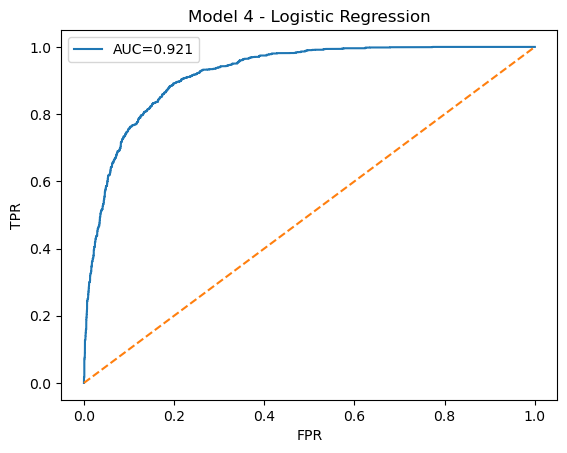

Training Random Forest


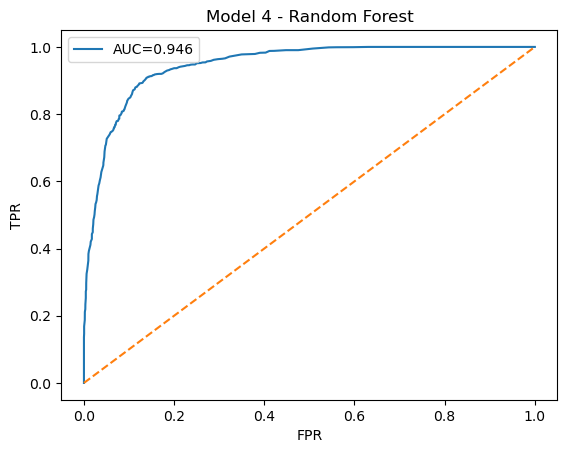

Training XGBoost


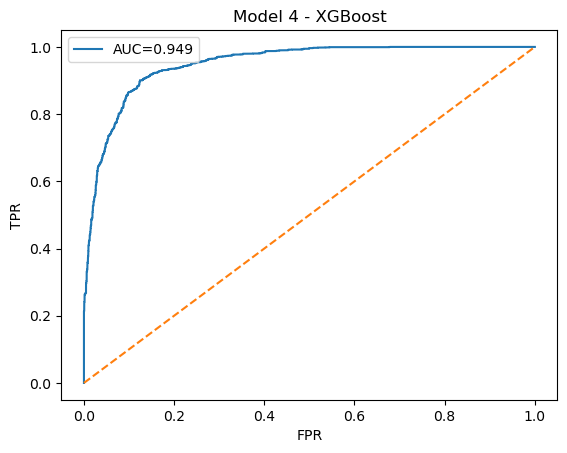

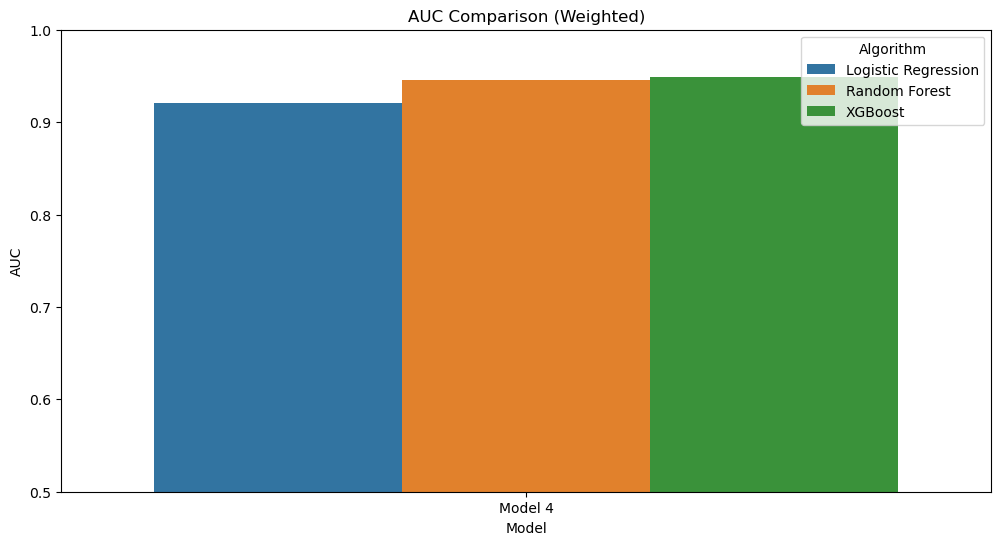

In [4]:
all_results = []
for name, features in models_map.items():

    print(f"\nProcessing {name}")

    df_clean = df.dropna(subset=features + [TARGET, WEIGHTS])

    # Filter to pre-generated train/test splits by SEQN
    df_train = df_clean[df_clean['SEQN_x'].isin(train_seqn)]
    df_test  = df_clean[df_clean['SEQN_x'].isin(test_seqn)]

    X_train = df_train[features]
    X_test  = df_test[features]
    y_train = df_train[TARGET]
    y_test  = df_test[TARGET]
    w_train = df_train[WEIGHTS]
    w_test  = df_test[WEIGHTS]

    # Preprocessing
    num_features = df_train[features].select_dtypes(include=np.number).columns.tolist()
    cat_features = ['RIAGENDR'] if 'RIAGENDR' in features else []

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first'), cat_features)
    ])

    classifiers = {
        "Logistic Regression": LogisticRegression(max_iter=3000, random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
        "XGBoost": XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=1,
            n_jobs=-1,
            random_state=42,
            eval_metric='logloss'
        )
    }

    for algo_name, model in classifiers.items():
        print(f"Training {algo_name}")

        pipe = Pipeline([
            ('prep', preprocessor),
            ('model', model)
        ])

        # Cross-validation: keep the best model across folds by validation AUC
        best_cv_loss = np.inf
        best_pipe = None
        cv_scores = []

        for fold_idx in range(N_FOLDS):
            fold_train_seqn = splits_data[f'fold_{fold_idx}_train']
            fold_val_seqn   = splits_data[f'fold_{fold_idx}_val']

            X_tr  = X_train[X_train.index.isin(df_clean[df_clean['SEQN_x'].isin(fold_train_seqn)].index)]
            X_val = X_train[X_train.index.isin(df_clean[df_clean['SEQN_x'].isin(fold_val_seqn)].index)]
            y_tr  = y_train[X_tr.index]
            y_val = y_train[X_val.index]
            w_tr  = w_train[X_tr.index]
            w_val = w_train[X_val.index]

            if len(X_tr) == 0 or len(X_val) == 0:
                continue

            import copy
            fold_pipe = copy.deepcopy(pipe)
            fold_pipe.fit(X_tr, y_tr, model__sample_weight=w_tr)
            y_val_prob = fold_pipe.predict_proba(X_val)[:, 1]
            score = roc_auc_score(y_val, y_val_prob, sample_weight=w_val)
            cv_scores.append(score)
            fold_loss = log_loss(y_val, y_val_prob, sample_weight=w_val)

            if fold_loss < best_cv_loss:
                best_cv_loss = fold_loss
                best_pipe = fold_pipe

        cv_auc_mean = np.mean(cv_scores) if cv_scores else float('nan')

        # Evaluate the best CV model on the test set
        y_prob = best_pipe.predict_proba(X_test)[:, 1]
        y_pred = best_pipe.predict(X_test)

        auc = roc_auc_score(y_test, y_prob, sample_weight=w_test)

        all_results.append({
            "Model": name,
            "Algorithm": algo_name,
            "AUC": round(auc, 4),
            "Accuracy": round(accuracy_score(y_test, y_pred, sample_weight=w_test), 4),
            "Precision": round(precision_score(y_test, y_pred, sample_weight=w_test), 4),
            "Recall": round(recall_score(y_test, y_pred, sample_weight=w_test), 4),
            "F1": round(f1_score(y_test, y_pred, sample_weight=w_test), 4),
            "LogLoss": round(log_loss(y_test, y_prob, sample_weight=w_test), 4),
            "CV_AUC": round(cv_auc_mean, 4)
        })

        fpr, tpr, _ = roc_curve(y_test, y_prob, sample_weight=w_test)
        plt.figure()
        plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
        plt.plot([0,1],[0,1],'--')
        plt.title(f"{name} - {algo_name}")
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.legend()
        plt.savefig(os.path.join(RESULT_DIR, f"ROC_{name}_{algo_name}.png"), dpi=300)
        plt.show()
        plt.close()

results_df = pd.DataFrame(all_results)
results_df.sort_values(by="AUC", ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(data=results_df, x='Model', y='AUC', hue='Algorithm')
plt.title("AUC Comparison (Weighted)")
plt.ylim(0.5, 1)
plt.savefig(os.path.join(RESULT_DIR, f"AUC_comparison.png"), dpi=300)
plt.show()
plt.close()

results_df.to_csv(f"{RESULT_DIR}/final_results.csv", index=False)
results_df.to_latex(f"{RESULT_DIR}/final_results.tex", index=False)


In [5]:
results_df.sort_values(by="AUC", ascending=False)


,Model,Algorithm,AUC,Accuracy,Precision,Recall,F1,LogLoss,CV_AUC
2,Model 4,XGBoost,0.9491,0.8859,0.8096,0.8184,0.8139,0.2621,0.9410
1,Model 4,Random Forest,0.9460,0.8819,0.8082,0.8036,0.8059,0.2723,0.9389
0,Model 4,Logistic Regression,0.9212,0.8543,0.7919,0.7085,0.7479,0.3341,0.9108
